In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

In [3]:
def simulate_rectangular_staggered_board(
    num_balls=10000, 
    rows=50, 
    cols=50,          # Maximum width of the board in terms of pegs
    spacing=2.5, 
    peg_radius=0.7, 
    ball_radius=0.0, 
    e=0.7, 
    sigma=5.0,        # Funnel width to either side of x=0 (Uniform distribution bounds)
    num_bins=80
):
    print(f"Starting simulation with {num_balls} balls...")
    print(f"Grid: {cols} pegs wide by {rows} rows tall (Rectangular Staggered)")
    print(f"Funnel release window: uniform from {-sigma} to {sigma}")
    
    g = 9.81
    dt = 0.005 
    effective_radius = peg_radius + ball_radius

    # 1. Generate Peg Positions (Rectangular Bounded Stagger)
    pegs = []
    for row in range(rows):
        y = -row * spacing * (np.sqrt(3) / 2)
        current_cols = cols if row % 2 == 0 else cols - 1
        
        for col in range(current_cols):
            x = (col - (current_cols - 1) / 2.0) * spacing
            pegs.append([x, y])
            
    pegs = np.array(pegs)

    print("Building spatial KD-Tree...")
    peg_tree = cKDTree(pegs)

    # 2. Initialize Ball States
    pos_x = np.random.uniform(-sigma, sigma, num_balls)
    pos_y = np.ones(num_balls) * 1.0  
    
    vel_x = np.zeros(num_balls)
    vel_y = np.zeros(num_balls)

    active = np.ones(num_balls, dtype=bool)
    final_x = np.zeros(num_balls)
    
    finish_line = -rows * spacing * (np.sqrt(3) / 2) - 2.0

    max_frames = 15000
    frame_count = 0

    # 3. Vectorized Physics Loop
    while np.any(active) and frame_count < max_frames:
        frame_count += 1
        
        vel_y[active] -= g * dt
        
        pos_x[active] += vel_x[active] * dt
        pos_y[active] += vel_y[active] * dt
        
        curr_x = pos_x[active]
        curr_y = pos_y[active]
        curr_vx = vel_x[active]
        curr_vy = vel_y[active]
        
        dist_hit, peg_indices = peg_tree.query(np.column_stack((curr_x, curr_y)), k=1)
        hit_mask = dist_hit < effective_radius
        
        if np.any(hit_mask):
            active_peg_indices = peg_indices[hit_mask]
            dist_hit_filtered = dist_hit[hit_mask]
            
            dx_hit = curr_x[hit_mask] - pegs[active_peg_indices, 0]
            dy_hit = curr_y[hit_mask] - pegs[active_peg_indices, 1]
            
            nx = dx_hit / dist_hit_filtered
            ny = dy_hit / dist_hit_filtered
            
            vx_hit = curr_vx[hit_mask]
            vy_hit = curr_vy[hit_mask]
            
            v_dot_n = vx_hit * nx + vy_hit * ny
            bounce_mask = v_dot_n < 0
            
            if np.any(bounce_mask):
                nx_b = nx[bounce_mask]
                ny_b = ny[bounce_mask]
                v_dot_n_b = v_dot_n[bounce_mask]
                
                impulse = -(1.0 + e) * v_dot_n_b
                
                hit_indices_in_active = np.where(hit_mask)[0]
                bounce_indices_in_active = hit_indices_in_active[bounce_mask]
                
                curr_vx[bounce_indices_in_active] += impulse * nx_b
                curr_vy[bounce_indices_in_active] += impulse * ny_b
                
                curr_vx[bounce_indices_in_active] += np.random.uniform(-0.02, 0.02, size=len(bounce_indices_in_active))
                
                overlap = effective_radius - dist_hit_filtered[bounce_mask]
                curr_x[bounce_indices_in_active] += nx_b * overlap
                curr_y[bounce_indices_in_active] += ny_b * overlap

        pos_x[active] = curr_x
        pos_y[active] = curr_y
        vel_x[active] = curr_vx
        vel_y[active] = curr_vy
        
        finished = pos_y < finish_line
        newly_finished = finished & active
        final_x[newly_finished] = pos_x[newly_finished]
        active = active & ~finished

    if frame_count >= max_frames:
        print(f"Warning: Reached max frames. {np.sum(active)} balls got stuck.")
        final_x[active] = pos_x[active] 

    # --- 4. Plotting Configuration ---
    max_x = (cols * spacing) / 2
    
    # FIX: Base the bin edges on the board width (max_x) instead of sigma
    bin_edges = np.linspace(-max_x, max_x, num_bins + 1)

    # GRAPH 1: Static Galton Board Setup with Buckets
    plt.figure(figsize=(10, 10))
    
    # FIX: Draw actual physical circles that respect the coordinate system
    ax = plt.gca()
    for peg in pegs:
        circle = plt.Circle((peg[0], peg[1]), peg_radius, color='darkslategray', alpha=0.4)
        ax.add_patch(circle)
        
    # Add a tiny center dot just so you can still see the peg grid structure
    plt.scatter(pegs[:, 0], pegs[:, 1], color='black', s=1, zorder=5)
    
    # Mark the funnel drop entry window (This stays relative to sigma)
    plt.hlines(1.0, -sigma, sigma, colors='red', linestyles='solid', linewidth=2, label='Funnel Release')
    
    # Draw the collection bucket dividers below the finish line
    bucket_top = finish_line
    bucket_bottom = finish_line - (rows * 0.1)
    
    # Draw vertical lines for each bin edge
    for edge in bin_edges:
        plt.vlines(edge, bucket_bottom, bucket_top, colors='royalblue', linestyles='-', alpha=0.4, linewidth=1)
    
    # FIX: Connect the bottoms of the slots across the entire board width
    plt.hlines(bucket_bottom, -max_x, max_x, colors='royalblue', alpha=0.4, linestyles='-')

    plt.title('Galton Board Setup (With Collection Buckets Mapped Below Grid)')
    plt.xlabel('Horizontal Position (X)')
    plt.ylabel('Vertical Position (Y)')
    plt.xlim(-max_x - 2, max_x + 2) 
    plt.ylim(bucket_bottom - 2, 3.0)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, alpha=0.2, linestyle='--')
    plt.legend(loc='upper right')
    
    # GRAPH 2: Standalone Histogram of Ball Final Positions
    plt.figure(figsize=(10, 5))
    plt.hist(final_x, bins=bin_edges, color='royalblue', edgecolor='black', zorder=3)
    
    variance = np.var(final_x)
    plt.title(f'Final Ball Distribution\nBalls: {num_balls} | e={e} | Variance ($\sigma^2$): {variance:.4f}')
    plt.xlabel('Horizontal Position (Bins)')
    plt.ylabel('Number of Balls')
    plt.xlim(-max_x - 2, max_x + 2) 
    plt.grid(axis='y', alpha=0.5, linestyle='--', zorder=0)
    
    plt.show()

<>:162: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:162: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Enda\AppData\Local\Temp\ipykernel_4452\3936451666.py:162: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title(f'Final Ball Distribution\nBalls: {num_balls} | e={e} | Variance ($\sigma^2$): {variance:.4f}')


Starting simulation with 5000 balls...
Grid: 50 pegs wide by 30 rows tall (Rectangular Staggered)
Funnel release window: uniform from -60 to 60
Building spatial KD-Tree...


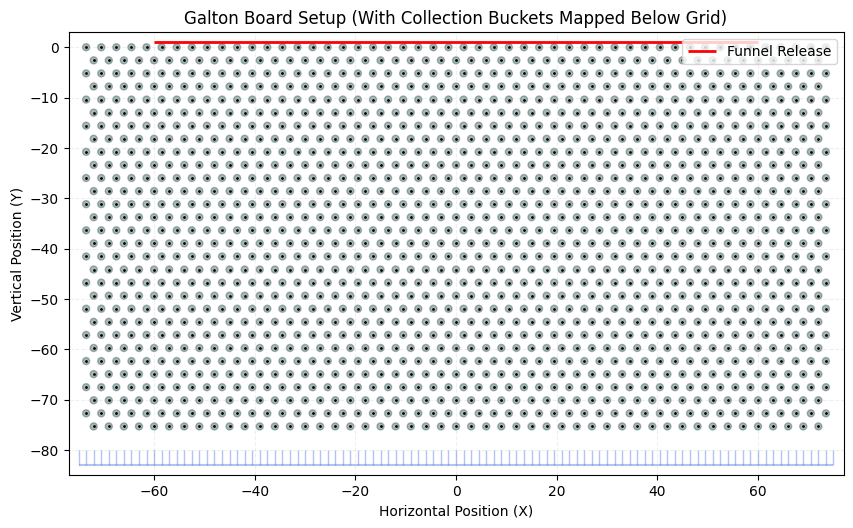

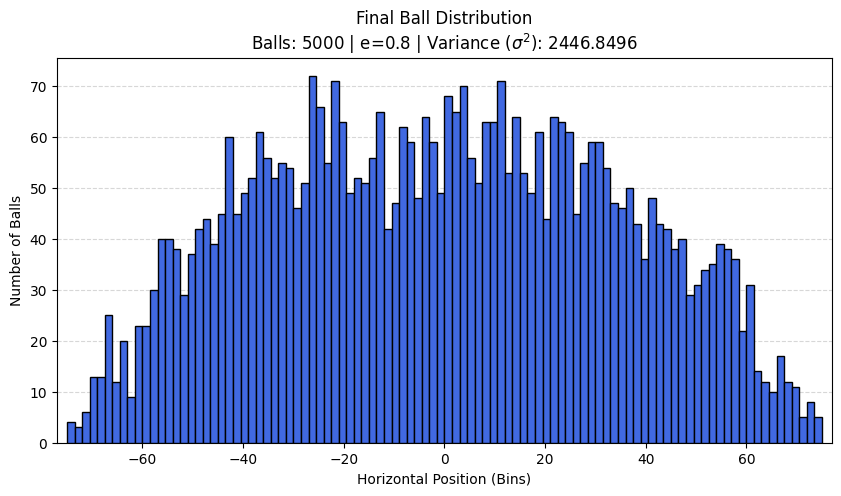

In [7]:
simulate_rectangular_staggered_board(
    num_balls=5000, 
    rows=30, 
    cols=50,
    spacing=3,
    peg_radius=0.7,
    ball_radius=0.0,
    e=0.8,
    sigma=60,
    num_bins=100
)